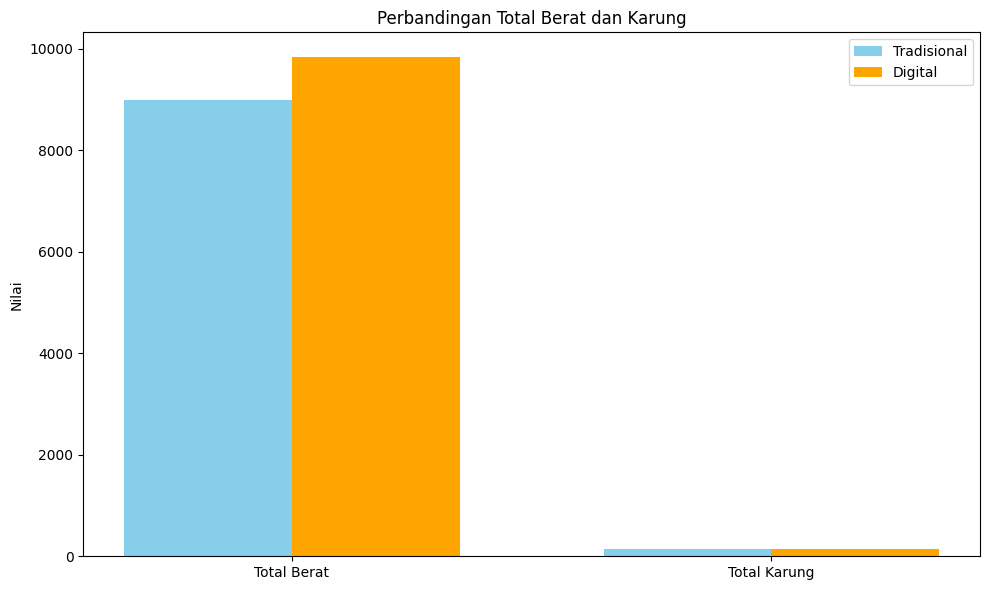

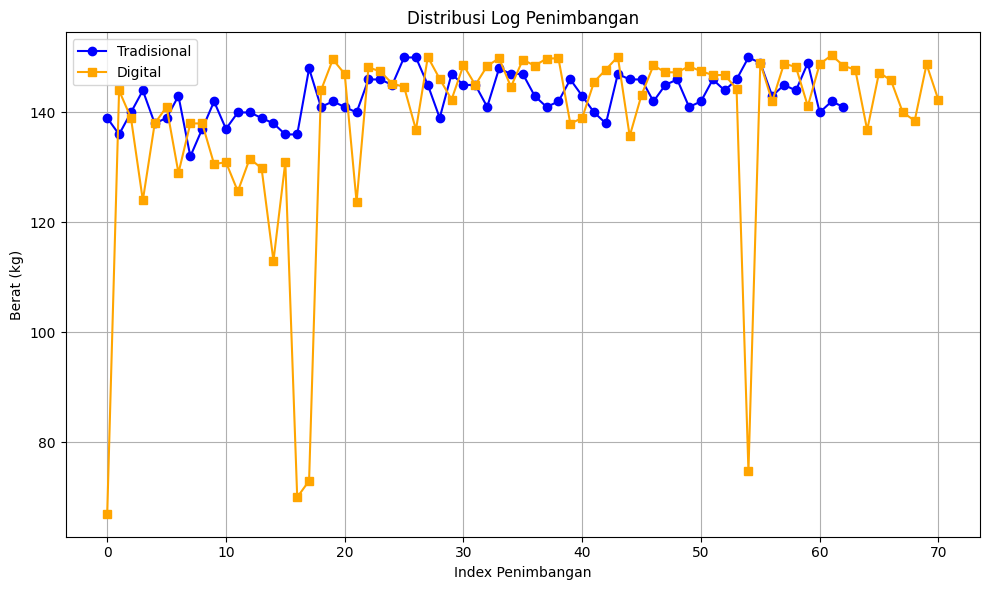

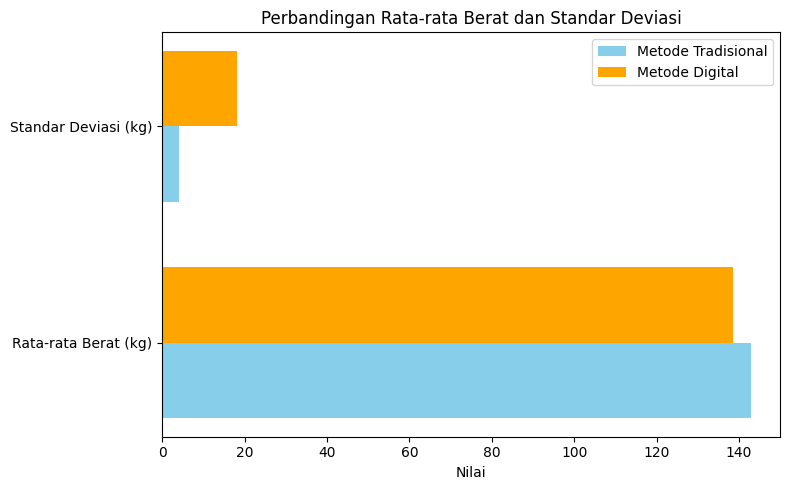

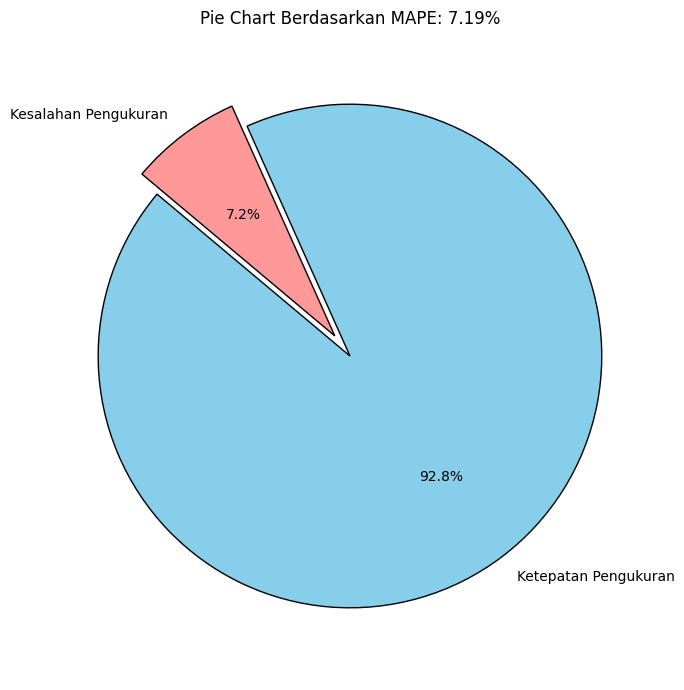

== Hasil Analisis ==

Rata-rata Berat per Karung:
  - Metode Tradisional: 142.79 kg
  - Metode Digital: 138.43 kg

Standar Deviasi (Variabilitas Pengukuran):
  - Metode Tradisional: 3.97 kg
  - Metode Digital: 18.13 kg

Total Berat Berdasarkan Log Penimbangan:
  - Metode Tradisional: 8996.00 kg
  - Metode Digital: 9828.45 kg

Selisih Berat antara Metode Tradisional dan Digital:
  - Selisih Berat: 832.45 kg

Nilai MAPE (Mean Absolute Percentage Error):
  - MAPE: 7.19%

Penjelasan MAPE:
MAPE menunjukkan tingkat akurasi antara dua metode pengukuran. Semakin rendah nilai MAPE, semakin akurat pengukuran tersebut.
Pada kasus ini, nilai MAPE sebesar 7.19% menunjukkan perbedaan yang cukup signifikan antara metode tradisional dan digital.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Variabel tradisional
tradisional = {
    'total_karung': 136,
    'durasi': 54 * 60 + 13,  # Konversi durasi ke detik
    'log_penimbangan': [139, 136, 140, 144, 138, 139, 143, 132, 137, 142, 137, 140, 140, 139, 138, 136, 136, 148, 141, 142, 141 , 140, 146, 146, 145, 150, 150, 145, 139, 147, 145, 145, 141, 148, 147, 147, 143, 141, 142, 146, 143, 140, 138, 147, 146, 146, 142, 145, 146, 141, 142, 146, 144, 146, 150, 149, 143, 145, 144, 149, 140, 142, 141]
}

# Variabel Digital
digital = {
    'total_karung': 138,
    'durasi': 54 * 60 + 13,  # Durasi dalam detik
    'log_penimbangan': [67.0, 144.0, 139.0, 124.0, 138.0, 141.0, 129.0, 138.0, 138.0, 130.6, 130.95, 125.65, 131.6, 129.85, 113.0, 131.0, 70.0, 73.0, 144.0, 149.65, 147.0, 123.7, 148.2, 147.45, 145.25, 144.65, 136.85, 150.1, 146.1, 142.35, 148.6, 145.0, 148.45, 149.85, 144.65, 149.6, 148.5, 149.8, 149.85, 137.95, 139.0, 145.55, 147.8, 150.15, 135.7, 143.2, 148.55, 147.3, 147.3, 148.4, 147.5, 146.8, 146.8, 144.3, 74.75, 149.0, 142.0, 148.9, 148.25, 141.15, 148.8, 150.4, 148.5, 147.75, 136.8, 147.25, 145.85, 140.0, 138.5, 148.75, 142.25]
}

# Perhitungan Total Berat Berdasarkan Log Penimbangan
total_berat_tradisional = np.sum(tradisional['log_penimbangan'])
total_berat_digital = np.sum(digital['log_penimbangan'])

# Statistik Deskriptif
mean_tradisional = np.mean(tradisional['log_penimbangan'])
mean_digital = np.mean(digital['log_penimbangan'])
std_tradisional = np.std(tradisional['log_penimbangan'])
std_digital = np.std(digital['log_penimbangan'])

# Selisih Berat
selisih_berat = abs(total_berat_digital - total_berat_tradisional)

# MAPE
mape = np.mean([abs((d - k) / k) for d, k in zip(digital['log_penimbangan'], tradisional['log_penimbangan'])]) * 100

# Visualisasi Data
plt.figure(figsize=(10, 6))

# Bar Plot untuk Total Berat dan Total Karung
labels = ['Total Berat', 'Total Karung']
tradisional_values = [total_berat_tradisional, tradisional['total_karung']]
digital_values = [total_berat_digital, digital['total_karung']]

x = np.arange(len(labels))
width = 0.35

# Menggunakan warna biru dan oranye seperti permintaan
plt.bar(x - width/2, tradisional_values, width, label='Tradisional', color='skyblue')
plt.bar(x + width/2, digital_values, width, label='Digital', color='orange')

plt.ylabel('Nilai')
plt.title('Perbandingan Total Berat dan Karung')
plt.xticks(x, labels)
plt.legend()

plt.tight_layout()
plt.show()

# Line Plot untuk Log Penimbangan
plt.figure(figsize=(10, 6))
plt.plot(tradisional['log_penimbangan'], label='Tradisional', marker='o', color='blue')
plt.plot(digital['log_penimbangan'], label='Digital', marker='s', color='orange')
plt.xlabel('Index Penimbangan')
plt.ylabel('Berat (kg)')
plt.title('Distribusi Log Penimbangan')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Grafik Bar Horizontal untuk Rata-rata Berat dan Standar Deviasi
categories = ['Rata-rata Berat (kg)', 'Standar Deviasi (kg)']
tradisional_values = [mean_tradisional, std_tradisional]
digital_values = [mean_digital, std_digital]

y_positions = np.arange(len(categories))
bar_width = 0.35

# Plotting Bar Horizontal
plt.figure(figsize=(8, 5))
plt.barh(y_positions - bar_width/2, tradisional_values, bar_width, label='Metode Tradisional', color='skyblue')
plt.barh(y_positions + bar_width/2, digital_values, bar_width, label='Metode Digital', color='orange')

# Menambahkan label, judul, dan legenda
plt.xlabel('Nilai')
plt.title('Perbandingan Rata-rata Berat dan Standar Deviasi')
plt.yticks(y_positions, categories)
plt.legend(loc='best')

# Menampilkan grafik
plt.tight_layout()
plt.show()

# Pie chart data based on MAPE
accuracy = 100 - mape 
error = mape 

# Data untuk pie chart
labels = ['Ketepatan Pengukuran', 'Kesalahan Pengukuran']
sizes = [accuracy, error]
colors = ['skyblue', '#ff9999'] 
explode = (0.1, 0) 

# Membuat pie chart
plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'black'})
plt.title(f'Pie Chart Berdasarkan MAPE: {mape:.2f}%')
plt.axis('equal')  
plt.tight_layout()
plt.show()


# Hasil Analisis yang Lebih Informatif
print("== Hasil Analisis ==\n")

# Rata-rata Berat per Karung
print(f"Rata-rata Berat per Karung:")
print(f"  - Metode Tradisional: {mean_tradisional:.2f} kg")
print(f"  - Metode Digital: {mean_digital:.2f} kg\n")

# Standar Deviasi (Variabilitas Pengukuran)
print(f"Standar Deviasi (Variabilitas Pengukuran):")
print(f"  - Metode Tradisional: {std_tradisional:.2f} kg")
print(f"  - Metode Digital: {std_digital:.2f} kg\n")

# Total Berat yang Dihasilkan
print(f"Total Berat Berdasarkan Log Penimbangan:")
print(f"  - Metode Tradisional: {total_berat_tradisional:.2f} kg")
print(f"  - Metode Digital: {total_berat_digital:.2f} kg\n")

# Selisih Berat antara tradisional dan Digital
print(f"Selisih Berat antara Metode Tradisional dan Digital:")
print(f"  - Selisih Berat: {selisih_berat:.2f} kg\n")

# MAPE (Mean Absolute Percentage Error)
print(f"Nilai MAPE (Mean Absolute Percentage Error):")
print(f"  - MAPE: {mape:.2f}%\n")

# Penjelasan tentang MAPE
print(f"Penjelasan MAPE:")
print(f"MAPE menunjukkan tingkat akurasi antara dua metode pengukuran. Semakin rendah nilai MAPE, semakin akurat pengukuran tersebut.")
print(f"Pada kasus ini, nilai MAPE sebesar {mape:.2f}% menunjukkan perbedaan yang cukup signifikan antara metode tradisional dan digital.")
